### 1c. Change of Mind and Individual Transition

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from scipy import stats
import starbars

cmap = mpl.colormaps['cool']

In [3]:
from spyglass.shijiegu.pairwiseDecode import replay_transitions,categorized_replay_transitions,behavior_transitions,behavior_transitions_count,findXCorrAllDays
from spyglass.shijiegu.changeOfMind_byTransition import find_COM_transitions, info2matrix

from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition

[2025-11-09 09:40:45,174][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
def return_neighbor_nonneighor(P_behavior):
    neighors = [(0,1),(1,0),(2,3),(3,2)]
    nonneighbors = [(0,2),(0,3),
                    (1,2),(1,3),
                    (2,0),(2,1),
                    (3,0),(3,1)]

    P_neighors = np.zeros(P_behavior.shape[2])
    P_nonneighors = np.zeros(P_behavior.shape[2])
    for n in neighors:
        P_neighors += P_behavior[n[0],n[1]]

    for n in nonneighbors:
        P_nonneighors += P_behavior[n[0],n[1]]
    return P_neighors / len(neighors), P_nonneighors / len(nonneighbors)

### legend

In [5]:
colors = np.array([["","C0","blueviolet","violet"],
          ["C1","","yellow","olive"],
          ["forestgreen","lime","","teal"],
          ["maroon","crimson","chocolate",""]])

# neighboring transitions are colored in orange, blue, others in grey
colors = np.array([["","C1","grey","grey"],
          ["C1","","grey","grey"],
          ["grey","grey","","C1"],
          ["grey","grey","C1",""]])

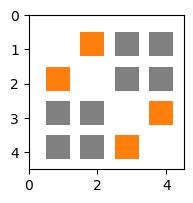

In [6]:
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 1, figsize=(2, 2),sharex=True)
for i in range(4):
    for j in range(4):
        if i == j:
            continue
        rect_ij = patches.Rectangle((j-0.5 + 1, i-0.5 + 1), 0.7, 0.7, linewidth=0.1, facecolor=colors[i,j])
        axes.add_patch(rect_ij)

axes.set_ylim(0, 4.5)
axes.set_xlim(0, 4.5)
axes.invert_yaxis()  # Invert the x-axis

In [7]:
def figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby):
    """all behavior"""
    P_behavior_all,xcorr_plot,xcorr25_plot,xcorr975_plot = behavior_transitions(animal,dates_to_plot,datafolder)
    C_behavior_all, C_behavior_reward_all = behavior_transitions_count(animal,dates_to_plot)
    #P_behavior = np.stack([P_behavior_all[P] for P in P_behavior_all], axis = 2)
    
    P_behavior_rewarded = np.stack([C_behavior_reward_all[C]/np.sum(C_behavior_all[C]) for C in C_behavior_reward_all], axis = 2)
    P_behavior = np.stack([C_behavior_all[C]/np.sum(C_behavior_all[C]) for C in C_behavior_all], axis = 2)
    P_behavior_unrewarded = np.stack([
        (C_behavior_all[C] - C_behavior_reward_all[C])/np.sum(C_behavior_all[C]) for C in C_behavior_all
        ], axis = 2)
    num_trials = [int(np.sum(C_behavior_all[C])) for C in C_behavior_all]
    
    """change of mind trials"""
    COM_all, COM_wouldhave_all = find_COM_transitions(animal, dates_to_plot, proportion_threshold = 0.05, nearby = nearby)
    COM_all = np.stack(COM_all, axis = 2)
    COM_wouldhave_all = np.stack(COM_wouldhave_all, axis = 2)
    
    data = {}
    data["num_trials"] = num_trials
    data["P_behavior"] = P_behavior
    data["P_behavior_unrewarded"] = P_behavior_unrewarded
    data["COM_all"] = COM_all
    data["COM_wouldhave_all"] = COM_wouldhave_all
    data["pre"] = pre
    data["post"] = post
    
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
    if nearby:
        file_path = f"{output_folder}/{animal_save_name}_bias_analysis_control.pickle"
    else:
        file_path = f"{output_folder}/{animal_save_name}_bias_analysis.pickle"
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")

    return success

### animals

In [16]:
success = {}
success_control = {}

In [19]:
animal = 'Molly'
animal_save_name = 'Molly'
dates_to_plot = ['20220415','20220416','20220417','20220418','20220419','20220420']
datafolder = '/stelmo/shijie/behavior_pilot/Batch1/' #f'/stelmo/shijie/behavior_pilot/Batch1/{animal}'
pre = ['20220415','20220416','20220417','20220418','20220419']
post = ['20220420']

success[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = False)
success_control[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = True)

[2025-10-08 13:58:10,815][WARNING]: Skipped checksum for file with hash: 708f7a32-5e94-6c46-2e36-a8b3ce983a59, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_ZMQ61DATFR.nwb
[13:58:20][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-08 13:58:20,432][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/nwb/analysis/molly20220415_7VU0N9KMWT.nwb
[2025-10-08 13:58:20,449][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/nwb/analysis/molly20220415_7VU0N9KMWT.nwb
[2025-10-08 13:58:20,453][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Molly_bias_analysis.pickle


[2025-10-08 14:09:50,922][WARNING]: Skipped checksum for file with hash: 708f7a32-5e94-6c46-2e36-a8b3ce983a59, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_ZMQ61DATFR.nwb
[14:09:59][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-08 14:10:00,005][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/nwb/analysis/molly20220415_7VU0N9KMWT.nwb
[2025-10-08 14:10:00,019][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/nwb/analysis/molly20220415_7VU0N9KMWT.nwb
[2025-10-08 14:10:00,024][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Molly_bias_analysis_control.pickle


In [20]:
animal = 'Eliot'
animal_save_name = 'Eliot'
dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/'
pre = ['20221018','20221019','20221020','20221021','20221022','20221023']
post = ['20221024','20221025','20221026']

#success[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = False)
success_control[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = True)

[2025-10-08 14:14:31,748][WARNING]: Skipped checksum for file with hash: d6f4e5f2-aff5-53ce-ec30-481b6c1fa138, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_K87P757N41.nwb
[14:14:36][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-08 14:14:36,983][WARNING]: Skipped checksum for file with hash: 5077f092-c506-baab-bd61-2874460b242c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_6A42Y6O7KW.nwb
[2025-10-08 14:14:36,997][WARNING]: Skipped checksum for file with hash: 5077f092-c506-baab-bd61-2874460b242c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_6A42Y6O7KW.nwb
[2025-10-08 14:14:37,001][WARNING]: Skipped checksum for file with hash: 5077f092-c506-baab-bd61-2874

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Eliot_bias_analysis_control.pickle


In [21]:
animal = 'Klein'
animal_save_name = 'Klein'
# " 20231110 has problems "
dates_to_plot = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']

pre = ['20231101','20231102','20231103','20231104','20231105','20231106','20231107','20231108']
post = ['20231109','20231111']

#success[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = False)
success_control[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = True)

[2025-10-08 14:22:38,660][WARNING]: Skipped checksum for file with hash: cb5de655-8a83-7fd5-fb16-105d230c6047, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_UT29JV8GXY.nwb
[14:22:47][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-08 14:22:47,865][WARNING]: Skipped checksum for file with hash: b18402fc-6402-d8ec-bd58-fd9416601c57, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_BF5DD5H5JZ.nwb
[2025-10-08 14:22:47,874][WARNING]: Skipped checksum for file with hash: b18402fc-6402-d8ec-bd58-fd9416601c57, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_BF5DD5H5JZ.nwb
[2025-10-08 14:22:47,878][WARNING]: Skipped checksum for file with hash: b18402fc-6402-d8ec-bd58-fd94

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Klein_bias_analysis_control.pickle


In [ ]:
animal = 'Lewis'
animal_save_name = 'Lewis1'
dates_to_plot = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
pre = ['20240105','20240106','20240107','20240108','20240109']
post = ['20240110','20240113','20240114']

#success[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = False)
success_control[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = True)

[2025-10-08 14:38:19,966][WARNING]: Skipped checksum for file with hash: 1cc15d5f-4f08-851d-9dea-6b68e196fc6b, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_IP1BV7QP74.nwb
[14:38:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-08 14:38:29,899][WARNING]: Skipped checksum for file with hash: 786a284d-72b7-bcdd-928c-347778e02367, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_DSB6NCLX3M.nwb
[2025-10-08 14:38:29,916][WARNING]: Skipped checksum for file with hash: 786a284d-72b7-bcdd-928c-347778e02367, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_DSB6NCLX3M.nwb
[2025-10-08 14:38:29,922][WARNING]: Skipped checksum for file with hash: 786a284d-72b7-bcdd-928c-3477

In [ ]:
animal = 'Julio'
animal_save_name = 'Julio'
dates_to_plot = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
pre = ['20230731','20230801','20230802','20230803','20230804',
       '20230805','20230806']
post = ['20230807','20230808','20230809','20230810','20230811']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

#success[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = False)
success_control[animal_save_name] = figure2(animal, animal_save_name, dates_to_plot, datafolder, pre, post, nearby = True)

### condensed plots:

In [8]:
# load all rats dates_to_plot, pre, post, P_behavior, COM_wouldhave_all,  COM_all

animals = ["Molly","Eliot","Klein","Lewis1","Julio"]

data = {}
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
for animal in animals:
    file_path = f"{output_folder}/{animal}_bias_analysis.pickle"
    with open(file_path, 'rb') as file:
        data[animal] = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")
        

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Molly_bias_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Eliot_bias_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Klein_bias_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Lewis1_bias_analysis.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/Julio_bias_analysis.pickle


#### 1) all behavior

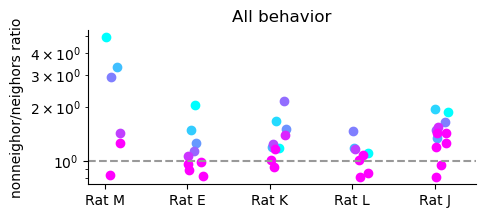

In [102]:
fig, axes = plt.subplots(1, 1, figsize=(5, 2),sharey = True)

animal_ind = 0
for animal in animals:
    data_animal = data[animal]
    
    (pre, post,
     P_behavior, COM_wouldhave_all,  COM_all) = (
         data_animal["pre"], data_animal["post"],
         data_animal["P_behavior"], data_animal["COM_wouldhave_all"], data_animal["COM_all"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)
    
    norm = Normalize(vmin=0, vmax=len(pre)-1)
    
    for ind in pre_ind + post_ind:
        ratio = P_nonneighors[ind]/P_neighors[ind]
        x_shift = np.random.rand(1)/5
        axes.scatter(np.zeros_like(ratio) + animal_ind + x_shift, ratio, color = cmap(norm(ind)))

    animal_ind += 1

# log scale
axes.set_yscale('log')

axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes.set_xlim([-0.2,len(animals)-0.5]);
axes.set_title("All behavior")
axes.set_ylabel("nonneighor/neighors ratio")
axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/all_behavior"
plt.savefig(file_path + ".pdf")
plt.savefig(file_path + ".png")

### linear over time

In [89]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}
import statsmodels.api as sm
import numpy.matlib as ml
import matplotlib.patheffects as PathEffects

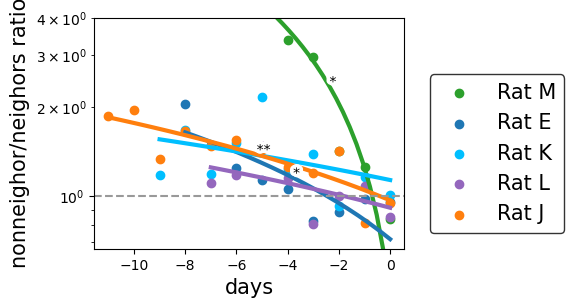

In [88]:
fig, axes = plt.subplots(1, 1, figsize=(4, 3))

animal_ind = 0
for animal in animals:
    data_animal = data[animal]
    
    (pre, post,
     P_behavior, COM_wouldhave_all,  COM_all) = (
         data_animal["pre"], data_animal["post"],
         data_animal["P_behavior"], data_animal["COM_wouldhave_all"], data_animal["COM_all"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)
    
    norm = Normalize(vmin=0, vmax=len(pre)-1)
    
    ratios = [P_nonneighors[ind]/P_neighors[ind] for ind in pre_ind + post_ind]
    x_indeces = np.array(pre_ind + post_ind)
    axes.scatter(x_indeces - x_indeces[-1], ratios,
                 color = color_by_rat[animal.lower()[:5]], label = f"Rat {animal[0].upper()}")
    #axes.plot(x_indeces - x_indeces[-1], ratios, color = color_by_rat[animal.lower()[:5]])
    X = sm.add_constant(x_indeces)

    # 3. Create and fit the OLS (Ordinary Least Squares) model
    model = sm.OLS(ratios, X)
    results = model.fit()

    X_pred = np.linspace(x_indeces[0],x_indeces[-1],20)
    X_pred = sm.add_constant(X_pred)
    X_plot = X_pred[:,-1] - x_indeces[-1]
    Y_pred = results.predict(X_pred)
    axes.plot(X_plot, Y_pred, color=color_by_rat[animal.lower()[:5]], linewidth = 3)
    pvalue = results.pvalues[1]
    mid_ind = int(len(X_plot)/2)
    if pvalue <= 0.001:
        txt = axes.text(X_plot[mid_ind], Y_pred[mid_ind], "**", color = 'k')
    elif pvalue <= 0.01:
        txt = axes.text(X_plot[mid_ind], Y_pred[mid_ind], "*", color = 'k')
    txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])


    #### add stats
    # t_statistic, p_value = stats.ttest_rel(P_neighors, P_nonneighors)
    # print("p_value",p_value)
    # axes.text(animal_ind + 0.1,5,str(np.round(p_value, 4)))
    ########

    animal_ind += 1

# log scale
axes.set_yscale('log')
legend = axes.legend(edgecolor = 'k',fontsize = 15, loc='upper left',bbox_to_anchor=(1.05, 0.8))
# Get the legend frame (which is a Rectangle object)
frame = legend.get_frame()
# Set the linewidth of the legend frame
frame.set_linewidth(1)


axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
#axes.set_xticks(np.arange(len(animals)));
#axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
#axes.set_xlim([-1,len(animals) + 1]);
axes.set_ylim([1/1.5,4]);
#axes.set_title("All behavior")
axes.set_ylabel("nonneighor/neighors ratio", fontsize = 15)
axes.set_xlabel("days", fontsize = 15)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/all_behavior_linear_regression"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

### Do a bit more stats: mixed linear

In [76]:
GLM_x = []
GLM_y = []

animal_ind = 0
for animal in animals:
    data_animal = data[animal]
    
    (pre, post,
     P_behavior, COM_wouldhave_all,  COM_all) = (
         data_animal["pre"], data_animal["post"],
         data_animal["P_behavior"], data_animal["COM_wouldhave_all"], data_animal["COM_all"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)
    
    norm = Normalize(vmin=0, vmax=len(pre)-1)

    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    ratios = [P_nonneighors[ind]/P_neighors[ind] for ind in pre_ind + post_ind]
    x_indeces = np.array(pre_ind + post_ind)
    X = x_indeces #- x_indeces[-1]
    X = X.reshape((-1,1))

    Y = np.array(ratios).reshape((-1,1))

    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))
    GLM_x.append(X)
    GLM_y.append(Y)

GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

In [70]:
#GLM_x

In [90]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["day"] = GLM_x[:,len(animals)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = np.log(GLM_y)

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()
print("p value of days:",ols_result1.pvalues[-1])

print("Mixed Linear Effect \n",ols_result1.summary())


p value of days: 7.930475641756752e-06
Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     10.34
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           2.29e-06
Time:                        10:48:39   Log-Likelihood:               -0.31898
No. Observations:                  45   AIC:                             12.64
Df Residuals:                      39   BIC:                             23.48
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

/tmp/ipykernel_2467445/3446804674.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("p value of days:",ols_result1.pvalues[-1])


In [91]:
np.exp(-0.07)

0.9323938199059483

#### 2) change of mind

p_value 0.004677529050682455
0.33 0.03
p_value 0.013199729278985042
1.43 0.03
p_value 0.005428682020072388
2.5300000000000002 0.03
p_value 0.0077118915400800955
3.63 0.03
p_value 0.002216120540436531
4.7299999999999995 0.03


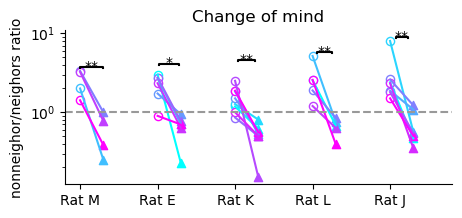

In [107]:
fig, axes = plt.subplots(1, 1, figsize=(5, 2),sharey = True)

animal_ind = 0
for animal in animals:
    data_animal = data[animal]
    (pre, post,
     P_behavior, COM_wouldhave_all,  COM_all) = (
         data_animal["pre"], data_animal["post"],
         data_animal["P_behavior"], data_animal["COM_wouldhave_all"], data_animal["COM_all"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    P_neighors_init, P_nonneighors_init = return_neighbor_nonneighor(COM_wouldhave_all)
    P_neighors_final, P_nonneighors_final = return_neighbor_nonneighor(COM_all)

    norm = Normalize(vmin=0, vmax=len(pre_ind)-1)

    ratio_init_all = []
    ratio_final_all = []
    for ind in pre_ind:
        if P_neighors_init[ind] == 0 or P_neighors_final[ind] == 0:
            continue
        ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
        ratio_final = P_nonneighors_final[ind]/P_neighors_final[ind]

        dot_size = 35
        axes.scatter(np.zeros_like(ratio_init) + animal_ind, ratio_init,
                     edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "o")
        axes.scatter(np.zeros_like(ratio_final) + animal_ind+0.3, ratio_final,
                     edgecolor = cmap(norm(ind)), facecolor = cmap(norm(ind)), s = dot_size, marker = "^")
        axes.plot(np.array([0,0.3]) + animal_ind,[ratio_init, ratio_final],color = cmap(norm(ind)))

        ratio_init_all.append(ratio_init)
        ratio_final_all.append(ratio_final)

    #### add stats
    t_statistic, p_value = stats.ttest_rel(np.log(ratio_init_all), np.log(ratio_final_all))
    print("p_value",p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))])
    ########
    
    animal_ind += 1

# log scale
axes.set_yscale('log')

axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes.set_xlim([-0.2,len(animals) - 0.2]);
axes.set_title("Change of mind")
axes.set_ylabel("nonneighor/neighors ratio")
axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/change_of_mind"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

### post

p_value nan
p_value 0.15641062245370277
p_value 0.1153854261043418
p_value 0.048106896575853084
3.63 0.03
p_value 0.0014411292865700565
4.7299999999999995 0.03


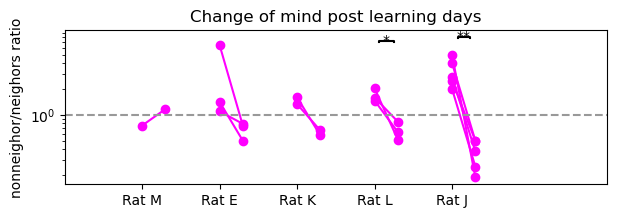

In [34]:
fig, axes = plt.subplots(1, 1, figsize=(7, 2),sharey = True)

animal_ind = 0
for animal in animals:
    data_animal = data[animal]
    (pre, post,
     P_behavior, COM_wouldhave_all,  COM_all) = (
         data_animal["pre"], data_animal["post"],
         data_animal["P_behavior"], data_animal["COM_wouldhave_all"], data_animal["COM_all"]
     )
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    P_neighors_init, P_nonneighors_init = return_neighbor_nonneighor(COM_wouldhave_all)
    P_neighors_final, P_nonneighors_final = return_neighbor_nonneighor(COM_all)

    norm = Normalize(vmin=0, vmax=len(pre_ind)-1)

    ratio_init_all = []
    ratio_final_all = []
    for ind in post_ind:
        if P_neighors_init[ind] == 0 or P_neighors_final[ind] == 0:
            continue
        ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
        ratio_final = P_nonneighors_final[ind]/P_neighors_final[ind]
        
        axes.scatter(np.zeros_like(ratio_init) + animal_ind, ratio_init, color = cmap(norm(ind)))
        axes.scatter(np.zeros_like(ratio_final) + animal_ind+0.3, ratio_final, color = cmap(norm(ind)))
        axes.plot(np.array([0,0.3]) + animal_ind,[ratio_init, ratio_final],color = cmap(norm(ind)))

        ratio_init_all.append(ratio_init)
        ratio_final_all.append(ratio_final)

    #### add stats
    t_statistic, p_value = stats.ttest_rel(np.log(ratio_init_all), np.log(ratio_final_all))
    print("p_value",p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))])
    ########
    
    animal_ind += 1

# log scale
axes.set_yscale('log')

axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes.set_xlim([-1,len(animals) + 1]);
axes.set_title("Change of mind post learning days")
axes.set_ylabel("nonneighor/neighors ratio")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/change_of_mind"
plt.savefig(file_path + "post.pdf")
plt.savefig(file_path + "post.png")

#### Comparing change of mind and nearby trials

In [26]:
# load all rats dates_to_plot, pre, post, P_behavior, COM_wouldhave_all,  COM_all

animals = ["Molly","Eliot","Klein","Lewis1","Julio"]

data = {}
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
for animal in animals:
    file_path = f"{output_folder}/{animal}_bias_analysis.pickle"
    with open(file_path, 'rb') as file:
        data[animal] = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Molly_bias_analysis.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Eliot_bias_analysis.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Klein_bias_analysis.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Lewis1_bias_analysis.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Julio_bias_analysis.pickle


In [24]:
# load all rats dates_to_plot, pre, post, P_behavior, COM_wouldhave_all,  COM_all

animals = ["Molly","Eliot","Klein","Lewis1","Julio"]

data_control = {}
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
for animal in animals:
    file_path = f"{output_folder}/{animal}_bias_analysis_control.pickle"
    with open(file_path, 'rb') as file:
        data_control[animal] = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")
        

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Molly_bias_analysis_control.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Eliot_bias_analysis_control.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Klein_bias_analysis_control.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Lewis1_bias_analysis_control.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/Julio_bias_analysis_control.pickle


p_value 0.09053990383170227
p_value 0.0002478973946536702
1.32 0.03
p_value 0.0636132075975659
p_value 0.3852429884621363
p_value 0.05078707949417436


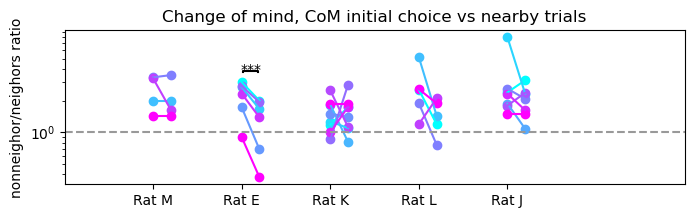

In [30]:
fig, axes = plt.subplots(1, 1, figsize=(8, 2),sharey = True)

animal_ind = 0
for animal in animals:
    data_animal = data[animal]
    data_control_animal = data_control[animal]
    (pre, post,
     P_behavior, COM_wouldhave_all,  COM_all) = (
         data_animal["pre"], data_animal["post"],
         data_animal["P_behavior"], data_animal["COM_wouldhave_all"], data_animal["COM_all"]
     )
    COM_all_cotrol = data_control_animal["COM_all"]
    dates_to_plot = pre + post
    
    ####
    pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
    post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
    ####
    
    P_neighors_init, P_nonneighors_init = return_neighbor_nonneighor(COM_wouldhave_all)
    P_neighors_final, P_nonneighors_final = return_neighbor_nonneighor(COM_all)
    P_neighors_final_control, P_nonneighors_final_control = return_neighbor_nonneighor(COM_all_cotrol)

    norm = Normalize(vmin=0, vmax=len(pre_ind)-1)

    ratio_init_all = []
    ratio_final_all = []
    for ind in pre_ind:
        if P_neighors_init[ind] == 0 or P_neighors_final[ind] == 0:
            continue
        ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
        ratio_final = P_nonneighors_final[ind]/P_neighors_final[ind]
        ratio_control = P_nonneighors_final_control[ind]/P_neighors_final_control[ind]
        
        axes.scatter(np.zeros_like(ratio_init) + animal_ind, ratio_init, color = cmap(norm(ind)))
        axes.scatter(np.zeros_like(ratio_control) + animal_ind+0.2, ratio_control, color = cmap(norm(ind)))
        axes.plot(np.array([0,0.2]) + animal_ind,[ratio_init, ratio_control],color = cmap(norm(ind)))
        #axes.plot(np.array([0.2,0.4]) + animal_ind,[ratio_final, ratio_control],color = cmap(norm(ind)))

        ratio_init_all.append(ratio_init)
        ratio_final_all.append(ratio_final)

    #### add stats
    t_statistic, p_value = stats.ttest_rel(np.log(ratio_init_all), np.log(ratio_control))
    print("p_value",p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.2, np.round(p_value, 4))])
    ########
    
    animal_ind += 1

# log scale
axes.set_yscale('log')

axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes.set_xlim([-1,len(animals) + 1]);
axes.set_title("Change of mind, CoM initial choice vs nearby trials")
axes.set_ylabel("nonneighor/neighors ratio")

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/change_of_mind"
plt.savefig(file_path + "CoMvsControl.pdf")
plt.savefig(file_path + "CoMvsControl.png")

#### colorbar

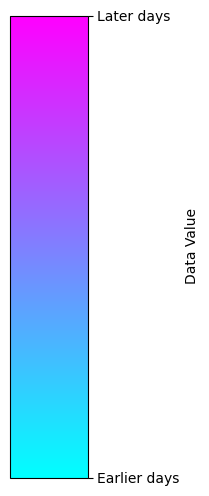

<Figure size 640x480 with 0 Axes>

In [168]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# 2. Define the normalization (how data values map to colors)
#    This specifies the range of values that the colormap will represent.
norm = mcolors.Normalize(vmin=0, vmax=100) # Example: data range from 0 to 100

# 3. Create a ScalarMappable object
#    This object links the colormap and normalization, making it "mappable".
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(np.linspace(0,100,100)) # An empty array is often used when there's no specific data to map

# 4. Create a figure and an axes for the colorbar
fig, ax = plt.subplots(figsize=(1, 6)) # Adjust size as needed for vertical colorbar

# 5. Draw the colorbar
#    Pass the ScalarMappable object and the axes where it should be drawn.
cbar = fig.colorbar(sm, cax=ax) # cax specifies the axes for the colorbar

# Define custom tick locations and labels
custom_ticks = [0, 100]
custom_labels = ['Earlier days','Later days']

# Set the ticks and tick labels of the colorbar
cbar.set_ticks(custom_ticks)
cbar.set_ticklabels(custom_labels)

# 6. Add a label to the colorbar (optional)
cbar.set_label('Data Value')

# 7. Display the plot
plt.show()

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure1/colorbar"
plt.savefig(file_path + ".pdf")
plt.savefig(file_path + ".png")

### End here

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(7, 4),sharey = True)

####
pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
####

P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)
P_neighors_init, P_nonneighors_init = return_neighbor_nonneighor(COM_wouldhave_all)
P_neighors_final, P_nonneighors_final = return_neighbor_nonneighor(COM_all)

norm = Normalize(vmin=0, vmax=len(P_neighors_init)-1)

ax = axes[0]
for ind in pre_ind:
    ratio = P_nonneighors[ind]/P_neighors[ind]
    ax.scatter(np.zeros_like(ratio) - 0.5,ratio,color = cmap(norm(ind)))
    
    ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
    ax.scatter(np.zeros_like(ratio),ratio_init,color = cmap(norm(ind)))

    ratio_final = P_nonneighors_final[ind]/P_neighors_final[ind]
    ax.scatter(np.zeros_like(ratio) + 1,ratio_final,color = cmap(norm(ind)))

    ax.plot([0,1],[ratio_init,ratio_final],color = cmap(norm(ind)))

ax.set_xticks([-0.5,0,1]);
ax.set_xticklabels(["All Choices","C.o.M. \n Initial Choice","C.o.M. \n final Choice"], rotation = 30);
ax.set_xlim([-1,1.5]);
ax.set_title(animal)
ax.set_ylabel("ratio")

# version 2
ax = axes[1]
for ind in pre_ind:
    ratio = P_nonneighors[ind]/P_neighors[ind]
    ax.scatter(np.zeros_like(ratio),ratio,color = cmap(norm(ind)))

ax.set_xticks([0]);
ax.set_xticklabels(["All Choices"], rotation = 30);
ax.set_xlim([-0.5,0.5]);

# version 3
ax = axes[2]
for ind in pre_ind:
    
    ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
    ax.scatter(np.zeros_like(ratio),ratio_init,color = cmap(norm(ind)))

    ratio_final = P_nonneighors_init[ind]/P_neighors_final[ind]
    ax.scatter(np.zeros_like(ratio) + 1,ratio_final,color = cmap(norm(ind)))

    ax.plot([0,1],[ratio_init,ratio_final],color = cmap(norm(ind)))

ax.set_xticks([0,1]);
ax.set_xticklabels(["C.o.M. \n Initial Choice","C.o.M. \n final Choice"], rotation = 30);
ax.set_xlim([-0.5,1.5]);



### other plots

#### (1) learning curve, session by session and day by day.

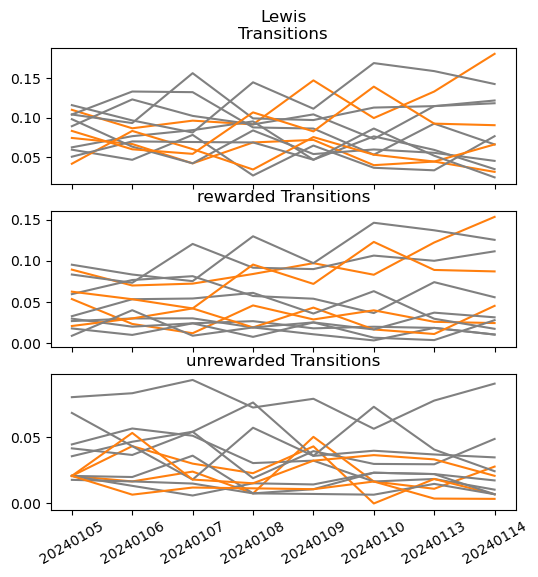

In [224]:
fig, axes = plt.subplots(3, 1, figsize=(6, 6),sharex=True)

for i in range(4):
    for j in range(4):
        if i == j:
            continue
        axes[0].plot(np.arange(len(dates_to_plot)), P_behavior[i,j,:], color = colors[i,j])
        axes[1].plot(np.arange(len(dates_to_plot)), P_behavior_rewarded[i,j,:], color = colors[i,j])
        axes[2].plot(np.arange(len(dates_to_plot)), P_behavior_unrewarded[i,j,:], color = colors[i,j])

axes[1].set_xticks(np.arange(len(dates_to_plot)));
axes[2].set_xticklabels(dates_to_plot, rotation = 30);
axes[0].set_title(f"{animal}\nTransitions");
axes[1].set_title(f"rewarded Transitions");
axes[2].set_title(f"unrewarded Transitions");

#### (2) change of mind behavior occurance

[2025-10-04 14:38:41,064][WARNING]: Skipped checksum for file with hash: 40f005ee-34c8-d92d-a60e-9b8cba50ce31, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_ATMU55PA2V.nwb
[14:38:49][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-04 14:38:49,971][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/nwb/analysis/molly20220415_7VU0N9KMWT.nwb
[2025-10-04 14:38:49,986][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/nwb/analysis/molly20220415_7VU0N9KMWT.nwb
[2025-10-04 14:38:49,992][WARNING]: Skipped checksum for file with hash: aea4e096-9f75-7857-2513-4d3d00e0e80e, and path: /stelmo/

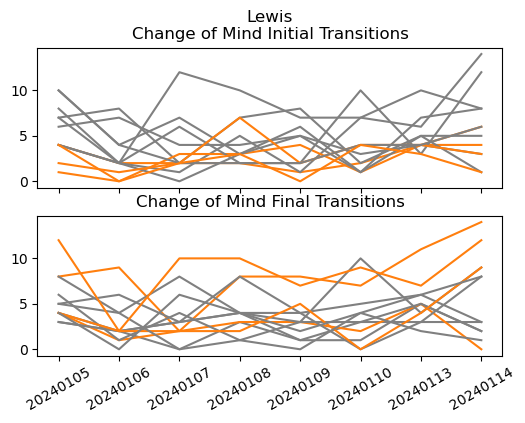

In [226]:
fig, axes = plt.subplots(2, 1, figsize=(6, 4),sharex=True)

for i in range(4):
    for j in range(4):
        if i == j:
            continue
        axes[0].plot(np.arange(len(dates_to_plot)), COM_wouldhave_all[i,j,:], color = colors[i,j])
        axes[1].plot(np.arange(len(dates_to_plot)), COM_all[i,j,:], color = colors[i,j])
        

axes[1].set_xticks(np.arange(len(dates_to_plot)));
axes[1].set_xticklabels(dates_to_plot, rotation = 30);

axes[0].set_title(animal);
axes[1].set_xticks(np.arange(len(dates_to_plot)));
axes[1].set_xticklabels(dates_to_plot, rotation = 30);

axes[0].set_title(f"{animal}\nChange of Mind Initial Transitions");
axes[1].set_title(f"Change of Mind Final Transitions");

In [ ]:
### More condensed plots

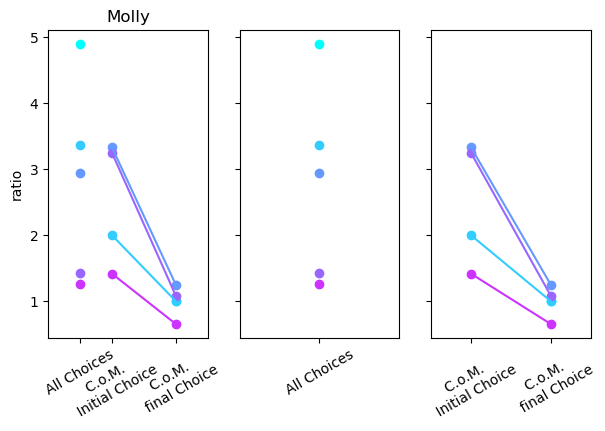

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(7, 4),sharey = True)

####
pre_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in pre]
post_ind = [ind for ind in range(len(dates_to_plot)) if dates_to_plot[ind] in post]
####

P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)
P_neighors_init, P_nonneighors_init = return_neighbor_nonneighor(COM_wouldhave_all)
P_neighors_final, P_nonneighors_final = return_neighbor_nonneighor(COM_all)

norm = Normalize(vmin=0, vmax=len(P_neighors_init)-1)

ax = axes[0]
for ind in pre_ind:
    ratio = P_nonneighors[ind]/P_neighors[ind]
    ax.scatter(np.zeros_like(ratio) - 0.5,ratio,color = cmap(norm(ind)))
    
    ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
    ax.scatter(np.zeros_like(ratio),ratio_init,color = cmap(norm(ind)))

    ratio_final = P_nonneighors_init[ind]/P_neighors_final[ind]
    ax.scatter(np.zeros_like(ratio) + 1,ratio_final,color = cmap(norm(ind)))

    ax.plot([0,1],[ratio_init,ratio_final],color = cmap(norm(ind)))

ax.set_xticks([-0.5,0,1]);
ax.set_xticklabels(["All Choices","C.o.M. \n Initial Choice","C.o.M. \n final Choice"], rotation = 30);
ax.set_xlim([-1,1.5]);
ax.set_title(animal)
ax.set_ylabel("ratio")

# version 2
ax = axes[1]
for ind in pre_ind:
    ratio = P_nonneighors[ind]/P_neighors[ind]
    ax.scatter(np.zeros_like(ratio),ratio,color = cmap(norm(ind)))

ax.set_xticks([0]);
ax.set_xticklabels(["All Choices"], rotation = 30);
ax.set_xlim([-0.5,0.5]);

# version 3
ax = axes[2]
for ind in pre_ind:
    
    ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
    ax.scatter(np.zeros_like(ratio),ratio_init,color = cmap(norm(ind)))

    ratio_final = P_nonneighors_init[ind]/P_neighors_final[ind]
    ax.scatter(np.zeros_like(ratio) + 1,ratio_final,color = cmap(norm(ind)))

    ax.plot([0,1],[ratio_init,ratio_final],color = cmap(norm(ind)))

ax.set_xticks([0,1]);
ax.set_xticklabels(["C.o.M. \n Initial Choice","C.o.M. \n final Choice"], rotation = 30);
ax.set_xlim([-0.5,1.5]);

